In [10]:
import pymc as pm, polars as pl, arviz as az
import numpy as np
import matplotlib.pyplot as plt

from utils import extract_quantile_columns, standardize_columns, plot_trace

In [11]:
df = pl.read_csv("../../Rethinking_2/End_of_chapter_problems/data/Primates301.csv", separator=";").filter((pl.col("brain") != "NA") &
                                                                                                          (pl.col("social_learning") != "NA") &
                                                                                                          (pl.col("research_effort") != "NA")).with_columns(
    log_brain=pl.col("brain").cast(pl.Float32).log(),
    social_learning=pl.col("social_learning").cast(pl.Float32),
    log_research_effort = pl.col("research_effort").cast(pl.Float32).log(),
).select("name", "genus", "species", "brain", "log_brain", "social_learning", "log_research_effort")

<Axes: xlabel='log_brain', ylabel='log_research_effort'>

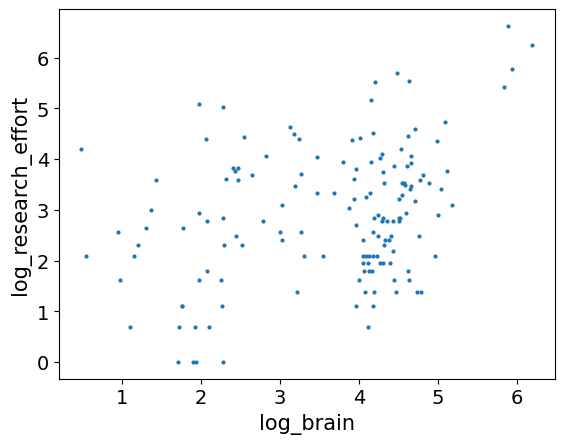

In [16]:
az.plot_pair(df.select("log_brain", "log_research_effort").to_dict())

In [12]:
with pm.Model() as basic_model:
    # data
    log_brain = pm.Data("log_brain", df["log_brain"].to_numpy())
    log_research_effort = pm.Data("log_research_effort", df["log_research_effort"].to_numpy())

    # priors
    alpha = pm.Normal("alpha", mu=0, sigma=0.2)
    beta_log_brain = pm.Normal("beta_log_brain", mu=0, sigma=0.3)
    beta_log_research_effort = pm.Normal("beta_log_research_effort", mu=0, sigma=0.3)

    # model definition
    log_lambda = pm.Deterministic("log_lambda", alpha + beta_log_brain*log_brain + beta_log_research_effort*log_research_effort)
    expected_count = pm.Deterministic("expected_count", pm.math.exp(log_lambda))

    social_learning = pm.Poisson("social_learning", expected_count, observed=df["social_learning"].to_numpy())

    # sample priors
    prior_predictive = pm.sample_prior_predictive(var_names=["social_learning", "expected_count"])

    # sample
    posterior = pm.sample(chains=4)
    posterior_predictive = pm.sample_posterior_predictive(posterior)
    pm.compute_log_likelihood(posterior)

Sampling: [alpha, beta_log_brain, beta_log_research_effort, social_learning]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_log_brain, beta_log_research_effort]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Sampling: [social_learning]


Output()

Output()

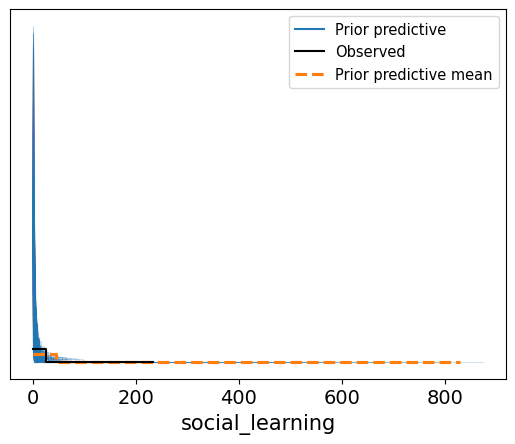

In [13]:
# prior predictive check
ax = az.plot_ppc(prior_predictive, group="prior", observed=True)

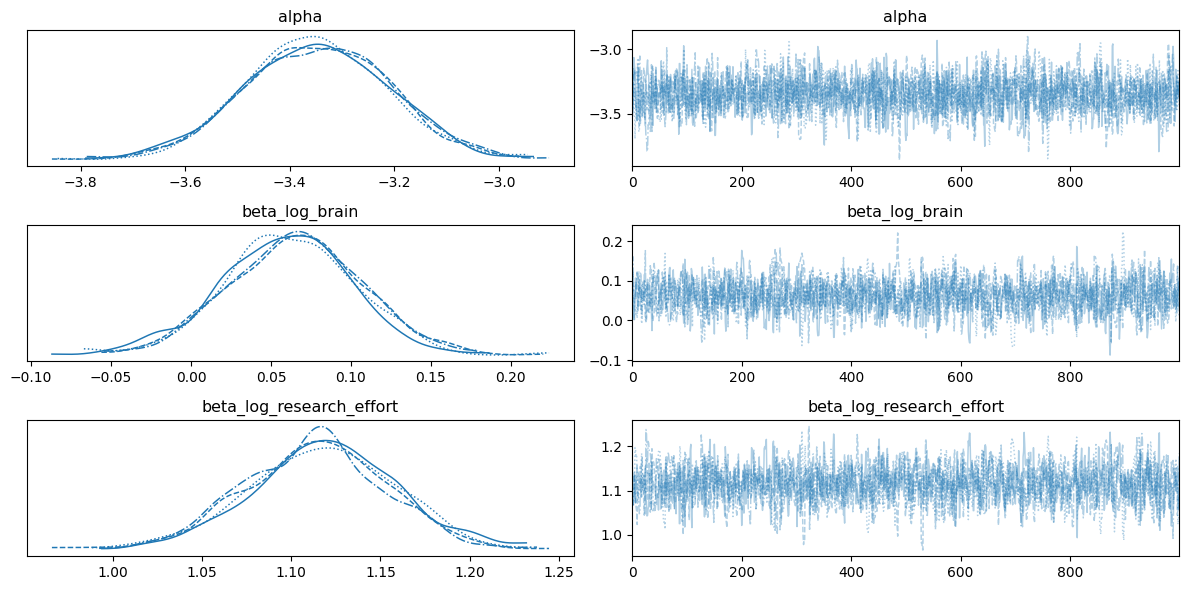

In [15]:
plot_trace(posterior, var_names=["alpha", "beta_log_brain", "beta_log_research_effort"])